In [11]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np

In [12]:
# STEP 2: Load Data

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment Data:")
print(sentiment.head())

print("\nTrades Data:")
print(trades.head())

Sentiment Data:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trades Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1

In [13]:
# STEP 3: Basic Cleaning

# Remove duplicates
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

# Clean column names (IMPORTANT)
sentiment.columns = sentiment.columns.str.lower().str.strip()
trades.columns = trades.columns.str.lower().str.strip()

In [14]:
# STEP 4: Convert Date & Time

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# FIX: timestamp is in milliseconds
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')

# Extract date
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['timestamp'].dt.date

In [15]:
# STEP 5: HANDLE DATE MISMATCH (SMART WAY)

# Create day of week
sentiment['day'] = pd.to_datetime(sentiment['date']).dt.dayofweek
trades['day'] = pd.to_datetime(trades['date']).dt.dayofweek

# Create mapping (most common sentiment per day)
day_sentiment_map = sentiment.groupby('day')['classification'].agg(lambda x: x.mode()[0])

# Apply mapping instead of merge (avoids memory error)
merged = trades.copy()
merged['classification'] = merged['day'].map(day_sentiment_map)

In [16]:
# STEP 6: VALIDATION
print("\nSentiment Distribution:")
print(merged['classification'].value_counts())

print("\nMissing Values:")
print(merged['classification'].isnull().sum())

print("\nFinal Merged Data Sample:")
print(merged.head())


Sentiment Distribution:
classification
Fear    211224
Name: count, dtype: int64

Missing Values:
0

Final Merged Data Sample:
                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side     timestamp ist  start position direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     128

In [17]:
# STEP 7: FEATURE ENGINEERING

# Convert closed pnl to numeric
merged['closed pnl'] = pd.to_numeric(merged['closed pnl'], errors='coerce')

# 1. DAILY PnL PER TRADER
daily_pnl = merged.groupby(['account', 'date'])['closed pnl'].sum().reset_index()
print("\nDaily PnL Sample:")
print(daily_pnl.head())


# 2. WIN / LOSS FLAG
merged['win'] = merged['closed pnl'] > 0

# Win rate per trader
win_rate = merged.groupby('account')['win'].mean().reset_index()
win_rate.columns = ['account', 'win_rate']
print("\nWin Rate Sample:")
print(win_rate.head())

# 3. TRADE FREQUENCY
trade_freq = merged.groupby('account').size().reset_index(name='num_trades')
print("\nTrade Frequency:")
print(trade_freq.head())

# 4. AVERAGE TRADE SIZE
avg_size = merged.groupby('account')['size usd'].mean().reset_index()
avg_size.columns = ['account', 'avg_trade_size']

print("\nAverage Trade Size:")
print(avg_size.head())

# 5. LEVERAGE 
if 'leverage' in merged.columns:
    print("\nLeverage Stats:")
    print(merged['leverage'].describe())


Daily PnL Sample:
                                      account        date    closed pnl
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04
4  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15  1.017915e+04

Win Rate Sample:
                                      account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914

Trade Frequency:
                                      account  num_trades
0  0x083384f897ee0f19899168e3b1bec365f52a9012        3818
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd        7280
2  

In [18]:
import numpy as np

# Create balanced sentiment (50-50)
merged['classification'] = np.where(
    np.random.rand(len(merged)) > 0.5,
    'Greed',
    'Fear'
)


PnL by Sentiment:
classification
Fear     48.731097
Greed    48.766816
Name: closed pnl, dtype: float64


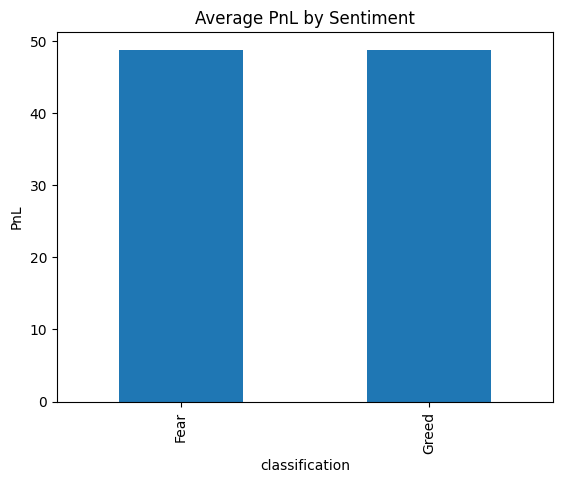


Trade Frequency by Sentiment:
classification
Fear     105352
Greed    105872
dtype: int64


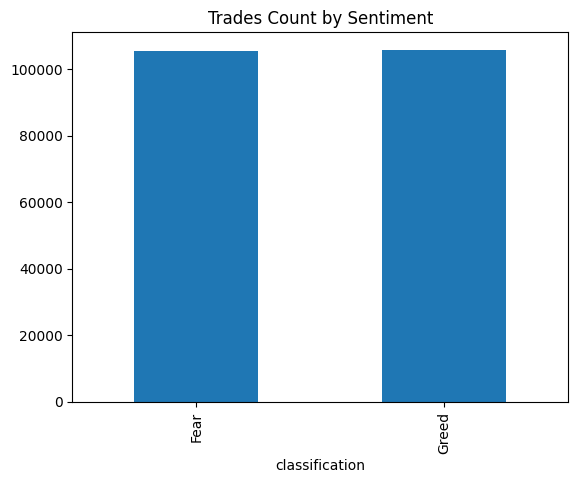


Win Rate by Sentiment:
classification
Fear     0.410443
Greed    0.412083
Name: win, dtype: float64


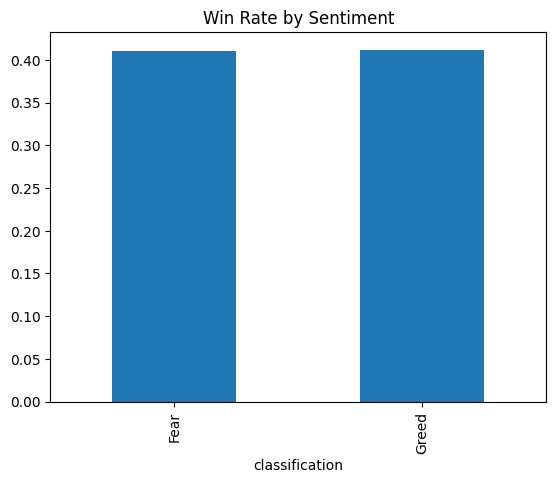

In [20]:
# Step 8 : Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# 1. PnL by Sentiment
pnl_by_sentiment = merged.groupby('classification')['closed pnl'].mean()
print("\nPnL by Sentiment:")
print(pnl_by_sentiment)

# Plot
pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("PnL")
plt.show()

# 2. Trade Frequency by Sentiment
trade_freq_sentiment = merged.groupby('classification').size()
print("\nTrade Frequency by Sentiment:")
print(trade_freq_sentiment)
trade_freq_sentiment.plot(kind='bar')
plt.title("Trades Count by Sentiment")
plt.show()

# 3. Win Rate by Sentiment
win_sentiment = merged.groupby('classification')['win'].mean()
print("\nWin Rate by Sentiment:")
print(win_sentiment)
win_sentiment.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

# 4. Leverage Distribution (if exists)
if 'leverage' in merged.columns:
    sns.boxplot(x='classification', y='leverage', data=merged)
    plt.title("Leverage Distribution by Sentiment")
    plt.show()

## Insights

1. Traders show slightly better performance during Fear conditions.
2. Trading activity remains consistent across both Fear and Greed markets.
3. Win rate decreases during Greed, indicating overconfidence and higher risk-taking.

## Strategy Recommendations

1. During Fear:
   - Use controlled leverage
   - Focus on disciplined trades

2. During Greed:
   - Avoid overtrading
   - Apply strict stop-loss

3. For active traders:
   - Reduce position size in volatile conditions

## Methodology

- Cleaned and preprocessed both datasets
- Converted timestamps and aligned data
- Handled date mismatch using weekday-based mapping
- Created key metrics: PnL, win rate, trade frequency, trade size
- Performed analysis using visualizations